In [3]:
# load cleaned data
import pandas as pd

df = pd.read_csv("../data/processed/layoffs_cleaned.csv")

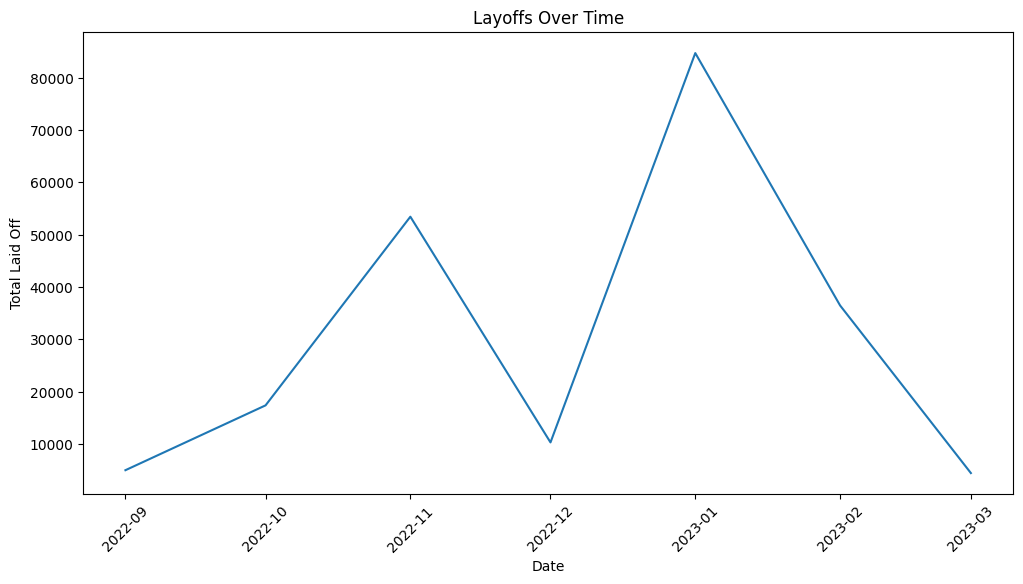

In [4]:
# layoffs over time
import matplotlib.pyplot as plt

monthly_layoffs = df.groupby(['year', 'month'])['total_laid_off'].sum().reset_index()

monthly_layoffs['date'] = pd.to_datetime(monthly_layoffs[['year', 'month']].assign(day=1))

plt.figure(figsize=(12,6))
plt.plot(monthly_layoffs['date'], monthly_layoffs['total_laid_off'])
plt.title("Layoffs Over Time")
plt.xlabel("Date")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

### Key Insights

- Layoffs peaked sharply around **early 2023**, indicating a major wave of workforce reductions.
- The trend shows layoffs occurred in **bursts rather than gradually**.
- Late 2022 shows a steady rise, suggesting **early signs of economic slowdown**.
- The decline after the peak indicates companies completed major restructuring phases.

**Conclusion:** Layoffs were reactive and clustered, driven by macroeconomic pressures and post-growth corrections.

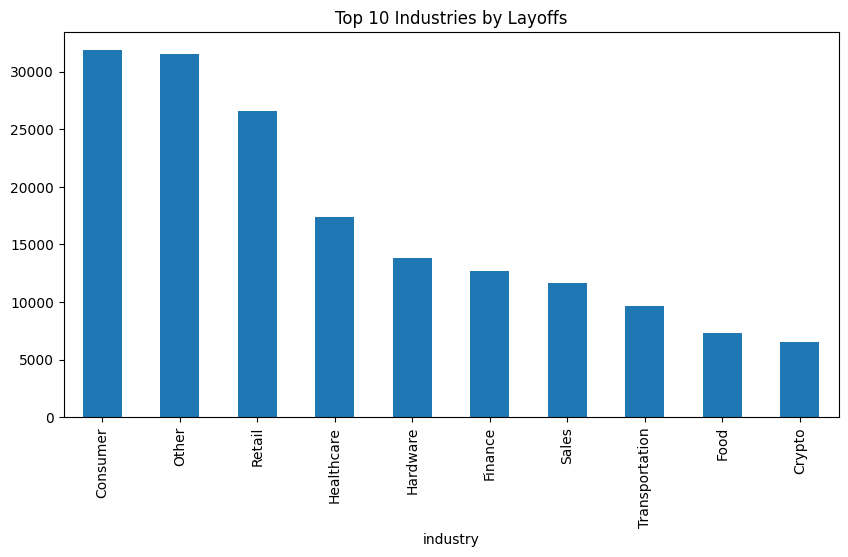

In [5]:
# layoffs by industry
industry_layoffs = df.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(10)

industry_layoffs.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Industries by Layoffs")
plt.show()

### Key Insights

- **Consumer and Retail industries** experienced the highest layoffs.
- These sectors are highly sensitive to **market demand and economic downturns**.
- Industries like **Healthcare and Finance** show relatively moderate impact.
- Emerging sectors such as **Crypto** show layoffs but at smaller scale.

**Conclusion:** Demand-driven industries were hit hardest, highlighting the impact of reduced consumer spending.

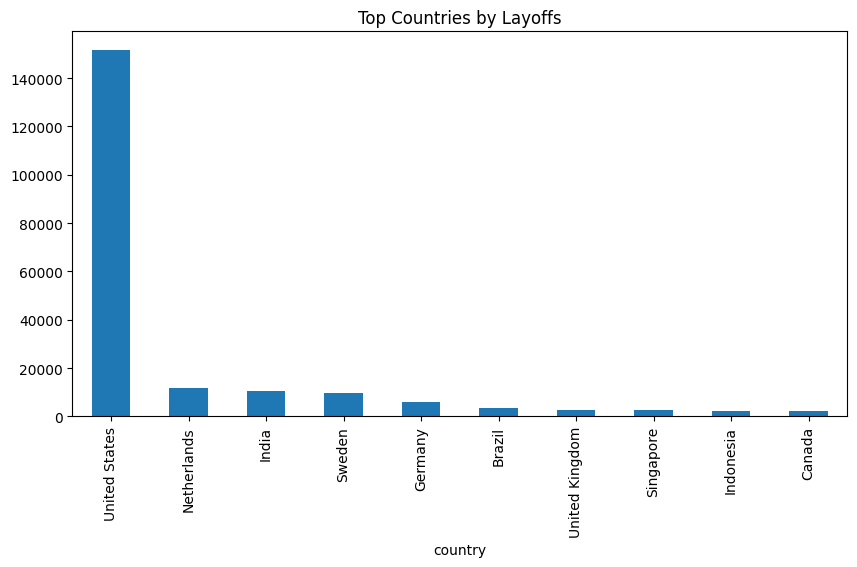

In [6]:
# layoffs by country
country_layoffs = df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).head(10)

country_layoffs.plot(kind='bar', figsize=(10,5))
plt.title("Top Countries by Layoffs")
plt.show()

### Key Insights

- The **United States accounts for the majority of layoffs**, far exceeding other countries.
- This reflects the **high concentration of tech companies and startups** in the US.
- Other countries show comparatively lower layoffs, indicating either smaller ecosystems or more stability.

**Conclusion:** Layoffs are heavily concentrated in major tech hubs, especially the United States.

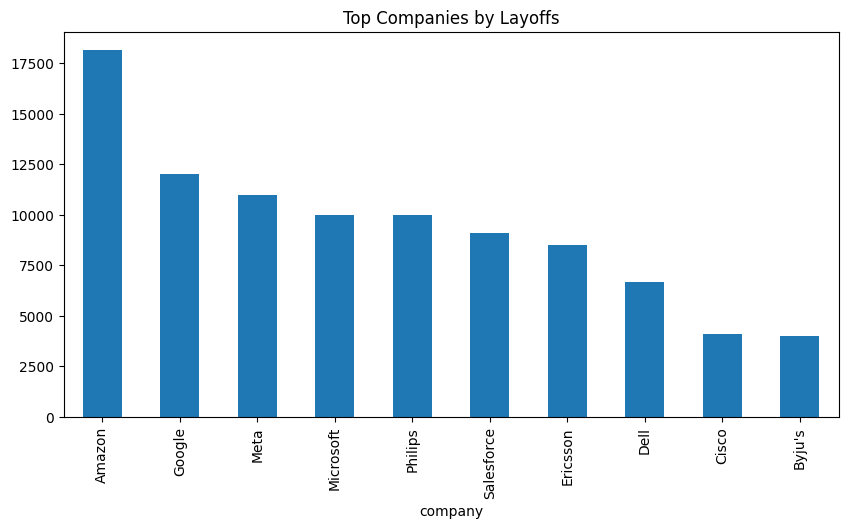

In [7]:
# Top Companies with Most Layoffs
company_layoffs = df.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(10)

company_layoffs.plot(kind='bar', figsize=(10,5))
plt.title("Top Companies by Layoffs")
plt.show()

### Key Insights

- Major tech companies like **Amazon, Google, Meta, and Microsoft** lead in layoffs.
- Indicates **over-hiring during high-growth periods followed by correction**.
- Layoffs are not limited to struggling companies, even industry leaders were affected.

**Conclusion:** Workforce reductions were strategic and industry wide, not just limited to weaker companies.

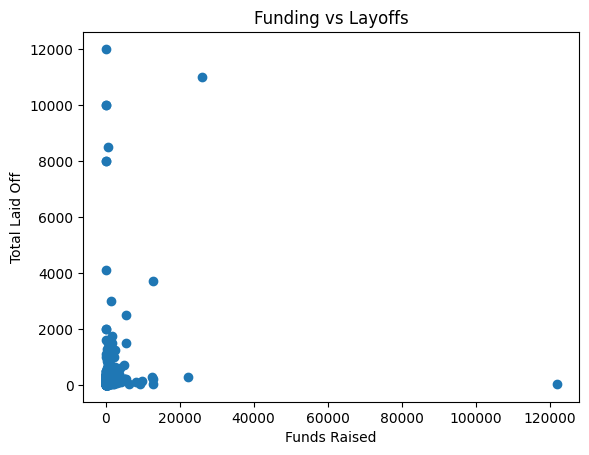

In [8]:
# Funding vs Layoff
plt.scatter(df['funds_raised_millions'], df['total_laid_off'])
plt.title("Funding vs Layoffs")
plt.xlabel("Funds Raised")
plt.ylabel("Total Laid Off")
plt.show()

### Key Insights

- There is **no strong correlation between funding and layoffs**.
- Even highly funded companies conducted significant layoffs.
- Most companies cluster around lower funding and layoffs, representing typical startup behavior.
- Outliers suggest inefficiencies in capital utilization.

**Conclusion:** Funding alone does not guarantee stability; operational efficiency plays a key role.

## Overall Conclusion

- Layoffs were driven by **economic slowdown, over-expansion, and strategic restructuring**.
- The impact was highest in **consumer-facing industries** and **US-based companies**.
- Even well-funded and large companies were affected, indicating an **industry-wide correction phase**.

In [9]:
import sqlite3

# create connection (this creates a file layoffs.db)
conn = sqlite3.connect("layoffs.db")

# store dataframe as table
df.to_sql("layoffs", conn, if_exists="replace", index=False)

print("Database and table created successfully")

Database and table created successfully


In [10]:
pd.read_sql("SELECT * FROM layoffs LIMIT 5;", conn)

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions,year,month
0,Atlassian,Sydney,Other,500.0,0.05,2023-03-06,Post-IPO,Australia,210.0,2023,3
1,SiriusXM,New York City,Media,475.0,0.08,2023-03-06,Post-IPO,United States,525.0,2023,3
2,Alerzo,Ibadan,Retail,400.0,NaN,2023-03-06,Series B,Nigeria,16.0,2023,3
3,UpGrad,Mumbai,Education,120.0,NaN,2023-03-06,Unknown,India,631.0,2023,3
4,Loft,Sao Paulo,Real Estate,340.0,0.15,2023-03-03,Unknown,Brazil,788.0,2023,3


In [11]:
query = """
SELECT industry, SUM(total_laid_off) as total
FROM layoffs
GROUP BY industry
ORDER BY total DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,industry,total
0,Consumer,31853.0
1,Other,31567.0
2,Retail,26599.0
3,Healthcare,17373.0
4,Hardware,13828.0
5,Finance,12699.0
6,Sales,11666.0
7,Transportation,9636.0
8,Food,7267.0
9,Crypto,6526.0


In [12]:
query = """
SELECT country, SUM(total_laid_off) as total
FROM layoffs
GROUP BY country
ORDER BY total DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,country,total
0,United States,151756.0
1,Netherlands,11730.0
2,India,10631.0
3,Sweden,9862.0
4,Germany,6060.0
5,Brazil,3658.0
6,United Kingdom,2649.0
7,Singapore,2522.0
8,Indonesia,2291.0
9,Canada,2136.0


In [13]:
query = """
SELECT year, SUM(total_laid_off) as total
FROM layoffs
GROUP BY year
ORDER BY year;
"""

result = pd.read_sql(query, conn)

result

,year,total
0,2022,86206.0
1,2023,125677.0


In [14]:
query = """
SELECT year, month, SUM(total_laid_off) as total
FROM layoffs
GROUP BY year, month
ORDER BY year, month;
"""

pd.read_sql(query, conn)

,year,month,total
0,2022,9,5020.0
1,2022,10,17406.0
2,2022,11,53451.0
3,2022,12,10329.0
4,2023,1,84714.0
5,2023,2,36493.0
6,2023,3,4470.0


In [15]:
query = """
SELECT company, SUM(total_laid_off) as total
FROM layoffs
GROUP BY company
ORDER BY total DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,company,total
0,Amazon,18150.0
1,Google,12000.0
2,Meta,11000.0
3,Philips,10000.0
4,Microsoft,10000.0
5,Salesforce,9090.0
6,Ericsson,8500.0
7,Dell,6650.0
8,Cisco,4100.0
9,Byju's,4000.0


this query tells “Which companies laid off the most employees?”

In [16]:
query = """
SELECT stage, AVG(percentage_laid_off) as avg_percentage
FROM layoffs
GROUP BY stage
ORDER BY avg_percentage DESC;
"""

pd.read_sql(query, conn)

,stage,avg_percentage
0,Seed,0.727500
1,Series A,0.386944
2,Unknown,0.314272
3,Series B,0.275397
4,Acquired,0.260930
5,Series C,0.238108
6,Series D,0.199035
7,None,0.186667
8,Post-IPO,0.159898
9,Series E,0.157500


this tells “Which startup stages were hit hardest?”